# Phase 5 — Model C: VAE (Variational Autoencoder)
## Blood Vessel Blockage Detection Project

**What is VAE?**
- VAE = Variational Autoencoder
- Regular Autoencoder se advanced version
- Normal blood flow seekhta hai → Jo alag hai = Blockage!

**Regular Autoencoder vs VAE:**
```
Regular AE: Input → Encode → Fixed Point → Decode → Output
VAE:        Input → Encode → Mean + Variance → Sample → Decode → Output
                              ↑           ↑
                         'Normal range'  'Uncertainty'
```

**Why VAE is better for medical anomaly detection?**
- Regular AE: Ek fixed point pe compress karta hai
- VAE: Distribution seekhta hai — 'Normal blood flow ka range kya hai?'
- Blockage wale patients → Distribution se bahar → High reconstruction error

**Architecture:**
```
ENCODER: Input(15) → Dense(64) → Dense(32) → [Mean(3), LogVar(3)]
                                                      ↓
                                             Reparameterization
                                                      ↓
DECODER: Z(3) → Dense(32) → Dense(64) → Output(15)
```

**Loss = Reconstruction Loss + KL Divergence**
- Reconstruction Loss: Input aur Output kitne similar hain
- KL Divergence: Latent space normal distribution ke kitna close hai

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

print('Libraries imported!')

Libraries imported!


---
## Step 1 — Load Phase 2 Labeled Data

In [2]:
df = pd.read_csv('phase2_labeled_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 19)


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv,velocity_ratio,thermal_stress,cardiac_load,vascular_resistance,flow_efficiency,blockage_score,blockage_label,confidence,risk_level
0,83.085284,0.696231,96.250183,36.574682,2.407925,6.796991,69.0,2.298226,0.196088,48.0,0.863222,16.366643,158.577612,0.136523,1.394930,0,0,High,Low Risk
1,129.254272,0.853361,64.919065,35.725150,3.708868,20.324207,113.0,0.840300,0.288642,24.0,1.991006,75.379801,94.953946,0.246316,0.574505,12,1,High,Critical Risk
2,105.756839,0.836293,64.084861,35.936101,4.405234,10.418063,86.0,1.151399,0.293710,56.0,1.650262,45.894002,99.020324,0.245627,0.745173,7,1,Medium,Critical Risk
3,133.971340,0.688480,69.625238,36.118859,3.347995,8.783595,94.0,1.752332,0.278041,50.0,1.924178,29.407435,164.719245,0.191426,0.740694,4,1,Low,High Risk
4,105.756839,0.696231,70.038666,36.995431,2.841834,5.616955,61.0,1.725171,0.212553,78.0,1.509978,15.962453,105.235446,0.147986,1.148175,0,0,High,Low Risk


In [3]:
feature_cols = [c for c in df.columns
                if c not in ['blockage_score','blockage_label','confidence','risk_level']]
X = df[feature_cols].values.astype(np.float64)
y = df['blockage_label'].values.astype(np.float64)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Normal   :', (y==0).sum())
print('Blockage :', (y==1).sum())

X shape: (2000, 15)
y shape: (2000,)
Normal   : 1153
Blockage : 847


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_temp,y_train,y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y)
X_val,X_test,y_val,y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# VAE sirf NORMAL data pe train hoga
# WHY? Normal pattern seekhega → Blockage = abnormal pattern
X_train_normal = X_train[y_train == 0]
X_val_normal   = X_val[y_val == 0]

print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)
print('VAE Training on NORMAL only:', X_train_normal.shape)

Train: (1400, 15) | Val: (300, 15) | Test: (300, 15)
VAE Training on NORMAL only: (807, 15)


---
## Step 2 — VAE Concept: Reparameterization Trick

**Problem:** Neural network mein random sampling se gradient nahi flow kar sakta

**Solution — Reparameterization Trick:**
```
❌ Direct sampling (gradient block):  z = sample(mean, std)

✅ Reparameterization (gradient flows):
   epsilon = sample(0, 1)    ← standard normal se sample
   z = mean + std * epsilon  ← deterministic operation
             ↑
       gradient yahan flow kar sakta hai!
```

**KL Divergence Loss:**
```
KL = -0.5 * sum(1 + log(var) - mean² - var)

Yeh latent space ko normal distribution ke paas rakhta hai
Taki similar patients similar latent points pe map hon
```

---
## Step 3 — VAE Architecture Implementation

In [5]:
class VAE:
    """
    Variational Autoencoder for Anomaly Detection
    
    ENCODER: 15 → 64 → 32 → [mean(3), logvar(3)]
    DECODER: 3  → 32 → 64 → 15
    
    Training: Normal data only
    Detection: High reconstruction error = Blockage
    """
    def __init__(self, input_dim=15, hidden_dim=64, latent_dim=3, lr=0.001):
        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.lr         = lr
        self.training   = True

        # ── ENCODER weights ──────────────────
        # Layer 1: input → hidden
        self.We1 = np.random.randn(input_dim,  hidden_dim) * np.sqrt(2./input_dim)
        self.be1 = np.zeros((1, hidden_dim))
        # Layer 2: hidden → hidden/2
        self.We2 = np.random.randn(hidden_dim, hidden_dim//2) * np.sqrt(2./hidden_dim)
        self.be2 = np.zeros((1, hidden_dim//2))
        # Mean head: hidden/2 → latent
        self.Wmu  = np.random.randn(hidden_dim//2, latent_dim) * np.sqrt(2./(hidden_dim//2))
        self.bmu  = np.zeros((1, latent_dim))
        # LogVar head: hidden/2 → latent
        self.Wlv  = np.random.randn(hidden_dim//2, latent_dim) * np.sqrt(2./(hidden_dim//2))
        self.blv  = np.zeros((1, latent_dim))

        # ── DECODER weights ──────────────────
        # Layer 1: latent → hidden/2
        self.Wd1 = np.random.randn(latent_dim,    hidden_dim//2) * np.sqrt(2./latent_dim)
        self.bd1 = np.zeros((1, hidden_dim//2))
        # Layer 2: hidden/2 → hidden
        self.Wd2 = np.random.randn(hidden_dim//2, hidden_dim) * np.sqrt(2./(hidden_dim//2))
        self.bd2 = np.zeros((1, hidden_dim))
        # Output: hidden → input
        self.Wd3 = np.random.randn(hidden_dim,    input_dim) * np.sqrt(2./hidden_dim)
        self.bd3 = np.zeros((1, input_dim))

        # ── Adam states (all weights) ─────────
        self._init_adam()

    def _init_adam(self):
        self.t = 0
        wnames = ['We1','be1','We2','be2','Wmu','bmu','Wlv','blv',
                  'Wd1','bd1','Wd2','bd2','Wd3','bd3']
        for w in wnames:
            setattr(self, f'm_{w}', np.zeros_like(getattr(self, w)))
            setattr(self, f'v_{w}', np.zeros_like(getattr(self, w)))

    # ── Activations ──────────────────────────
    def relu(self, x):    return np.maximum(0, x)
    def drelu(self, x):   return (x > 0).astype(np.float64)

    # ── ENCODER ──────────────────────────────
    def encode(self, X):
        """
        Input → Hidden → Mean, LogVar
        Returns: mu, logvar, h1, h2 (cache for backprop)
        """
        self.enc_in = X
        z1 = X @ self.We1 + self.be1
        h1 = self.relu(z1)
        z2 = h1 @ self.We2 + self.be2
        h2 = self.relu(z2)

        mu     = h2 @ self.Wmu + self.bmu   # mean
        logvar = h2 @ self.Wlv + self.blv   # log variance

        self.z1=z1; self.h1=h1; self.z2=z2; self.h2=h2
        return mu, logvar

    # ── REPARAMETERIZATION ────────────────────
    def reparameterize(self, mu, logvar):
        """
        Reparameterization Trick:
        z = mu + std * epsilon
        epsilon ~ N(0,1)  ← random noise
        
        Training: sample karo (stochastic)
        Testing : sirf mean use karo (deterministic)
        """
        if self.training:
            std     = np.exp(0.5 * logvar)     # std = exp(logvar/2)
            epsilon = np.random.randn(*mu.shape)
            return mu + std * epsilon
        else:
            return mu   # testing mein sirf mean

    # ── DECODER ──────────────────────────────
    def decode(self, z):
        """
        Latent vector → Reconstructed Input
        """
        self.dec_in = z
        dz1 = z  @ self.Wd1 + self.bd1
        dh1 = self.relu(dz1)
        dz2 = dh1 @ self.Wd2 + self.bd2
        dh2 = self.relu(dz2)
        out = dh2 @ self.Wd3 + self.bd3   # linear output (regression)

        self.dz1=dz1; self.dh1=dh1; self.dz2=dz2; self.dh2=dh2
        return out

    # ── FULL FORWARD ─────────────────────────
    def forward(self, X):
        self.mu, self.logvar = self.encode(X)
        self.z   = self.reparameterize(self.mu, self.logvar)
        self.xhat = self.decode(self.z)
        return self.xhat

    # ── VAE LOSS ─────────────────────────────
    def vae_loss(self, X, xhat, mu, logvar, beta=1.0):
        """
        VAE Loss = Reconstruction Loss + beta * KL Divergence

        Reconstruction Loss (MSE):
            How well did we reconstruct the input?
            Low = Model understood the pattern

        KL Divergence:
            KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
            Latent space ko N(0,1) ke paas rakhta hai
            Low = Latent space well-organized

        beta: KL term ka weight (beta-VAE)
            beta=1  → standard VAE
            beta>1  → better disentanglement
        """
        # Reconstruction loss
        recon_loss = np.mean((X - xhat)**2)

        # KL Divergence
        kl_loss = -0.5 * np.mean(
            1 + logvar - mu**2 - np.exp(logvar)
        )

        return recon_loss + beta * kl_loss, recon_loss, kl_loss

    # ── BACKWARD ─────────────────────────────
    def backward(self, X, beta=1.0):
        B = X.shape[0]

        # ── Decoder gradients ──
        d_out = 2*(self.xhat - X) / B          # dL/d_output
        self.dWd3 = self.dh2.T @ d_out
        self.dbd3 = d_out.sum(0, keepdims=True)
        d = d_out @ self.Wd3.T * self.drelu(self.dz2)
        self.dWd2 = self.dh1.T @ d
        self.dbd2 = d.sum(0, keepdims=True)
        d = d @ self.Wd2.T * self.drelu(self.dz1)
        self.dWd1 = self.dec_in.T @ d
        self.dbd1 = d.sum(0, keepdims=True)
        dz = d @ self.Wd1.T                    # gradient flows to latent z

        # ── Reparameterization gradients ──
        std  = np.exp(0.5 * self.logvar)
        dmu     = dz + beta * self.mu / B      # from KL
        dlogvar = (dz * (self.z - self.mu) * 0.5
                   + beta * 0.5 * (np.exp(self.logvar) - 1) / B)

        # ── Encoder gradients ──
        self.dWmu  = self.h2.T @ dmu
        self.dbmu  = dmu.sum(0, keepdims=True)
        self.dWlv  = self.h2.T @ dlogvar
        self.dblv  = dlogvar.sum(0, keepdims=True)
        d_h2 = (dmu @ self.Wmu.T + dlogvar @ self.Wlv.T) * self.drelu(self.z2)
        self.dWe2 = self.h1.T @ d_h2
        self.dbe2 = d_h2.sum(0, keepdims=True)
        d_h1 = d_h2 @ self.We2.T * self.drelu(self.z1)
        self.dWe1 = self.enc_in.T @ d_h1
        self.dbe1 = d_h1.sum(0, keepdims=True)

    # ── ADAM OPTIMIZER ───────────────────────
    def adam_step(self, b1=0.9, b2=0.999, eps=1e-8):
        self.t += 1
        wnames = ['We1','be1','We2','be2','Wmu','bmu','Wlv','blv',
                  'Wd1','bd1','Wd2','bd2','Wd3','bd3']
        for wn in wnames:
            g  = getattr(self, f'd{wn}')
            m  = b1*getattr(self,f'm_{wn}') + (1-b1)*g
            v  = b2*getattr(self,f'v_{wn}') + (1-b2)*g**2
            setattr(self,f'm_{wn}',m); setattr(self,f'v_{wn}',v)
            mh = m/(1-b1**self.t); vh = v/(1-b2**self.t)
            w  = getattr(self, wn)
            setattr(self, wn, w - self.lr*mh/(np.sqrt(vh)+eps))

    # ── RECONSTRUCTION ERROR (Anomaly Score) ─
    def reconstruction_error(self, X):
        """
        Error = Mean((X - X_reconstructed)^2) per sample
        Normal patients     → Low error  (model ne samjha)
        Blockage patients   → High error (pattern unfamiliar)
        """
        self.training = False
        xhat = self.forward(X)
        return np.mean((X - xhat)**2, axis=1)

print('VAE class defined!')
print('Architecture:')
print('  ENCODER: 15 → 64 → 32 → [Mean(3), LogVar(3)]')
print('  DECODER:  3 → 32 → 64 → 15')
print('  Loss: MSE + KL Divergence')

VAE class defined!
Architecture:
  ENCODER: 15 → 64 → 32 → [Mean(3), LogVar(3)]
  DECODER:  3 → 32 → 64 → 15
  Loss: MSE + KL Divergence


---
## Step 4 — Train VAE on Normal Data Only

In [6]:
np.random.seed(42)
vae = VAE(input_dim=15, hidden_dim=64, latent_dim=3, lr=0.001)

train_losses, val_losses = [], []
recon_losses, kl_losses  = [], []
best_val=np.inf; patience=0; best_weights=None; stopped_at=150

print('Training VAE on NORMAL samples only...')
print(f"{'Epoch':>6} | {'Total Loss':>10} | {'Recon Loss':>10} | {'KL Loss':>8} | {'Val Loss':>9}")
print('─'*60)

for epoch in range(150):
    vae.training = True
    idx = np.random.permutation(len(X_train_normal))
    Xs  = X_train_normal[idx]
    ep_loss, ep_recon, ep_kl = [], [], []

    for s in range(0, len(X_train_normal), 32):
        Xb   = Xs[s:s+32]
        xhat = vae.forward(Xb)
        loss, rl, kl = vae.vae_loss(Xb, xhat, vae.mu, vae.logvar, beta=1.0)
        vae.backward(Xb, beta=1.0)
        vae.adam_step()
        ep_loss.append(loss); ep_recon.append(rl); ep_kl.append(kl)

    # Validation
    vae.training = False
    xhat_val = vae.forward(X_val_normal)
    vl, _, _ = vae.vae_loss(X_val_normal, xhat_val, vae.mu, vae.logvar)

    tl = np.mean(ep_loss); rl = np.mean(ep_recon); kl = np.mean(ep_kl)
    train_losses.append(tl); val_losses.append(float(vl))
    recon_losses.append(rl); kl_losses.append(kl)

    if (epoch+1) % 15 == 0 or epoch == 0:
        print(f"{epoch+1:>6} | {tl:>10.4f} | {rl:>10.4f} | {kl:>8.4f} | {float(vl):>9.4f}")

    if vl < best_val:
        best_val=vl; patience=0
        best_weights = {w: getattr(vae,w).copy()
                        for w in ['We1','be1','We2','be2','Wmu','bmu','Wlv','blv',
                                  'Wd1','bd1','Wd2','bd2','Wd3','bd3']}
    else:
        patience+=1
        if patience>=15:
            stopped_at=epoch+1
            print(f'\n  Early Stopping at Epoch {epoch+1}')
            break

# Restore best weights
for w,v in best_weights.items(): setattr(vae, w, v)
print('─'*60)
print('Training complete! Best weights restored.')

Training VAE on NORMAL samples only...
 Epoch | Total Loss | Recon Loss |  KL Loss |  Val Loss
────────────────────────────────────────────────────────────
     1 |     2.0317 |     1.6075 |   0.4242 |    1.1599
    15 |     0.8445 |     0.3004 |   0.5441 |    0.7964
    30 |     0.7813 |     0.2808 |   0.5006 |    0.7119
    45 |     0.7374 |     0.2708 |   0.4666 |    0.6601
    60 |     0.7315 |     0.2604 |   0.4711 |    0.6389
    75 |     0.7212 |     0.2555 |   0.4658 |    0.6388

  Early Stopping at Epoch 76
────────────────────────────────────────────────────────────
Training complete! Best weights restored.


---
## Step 5 — Training Loss Curves

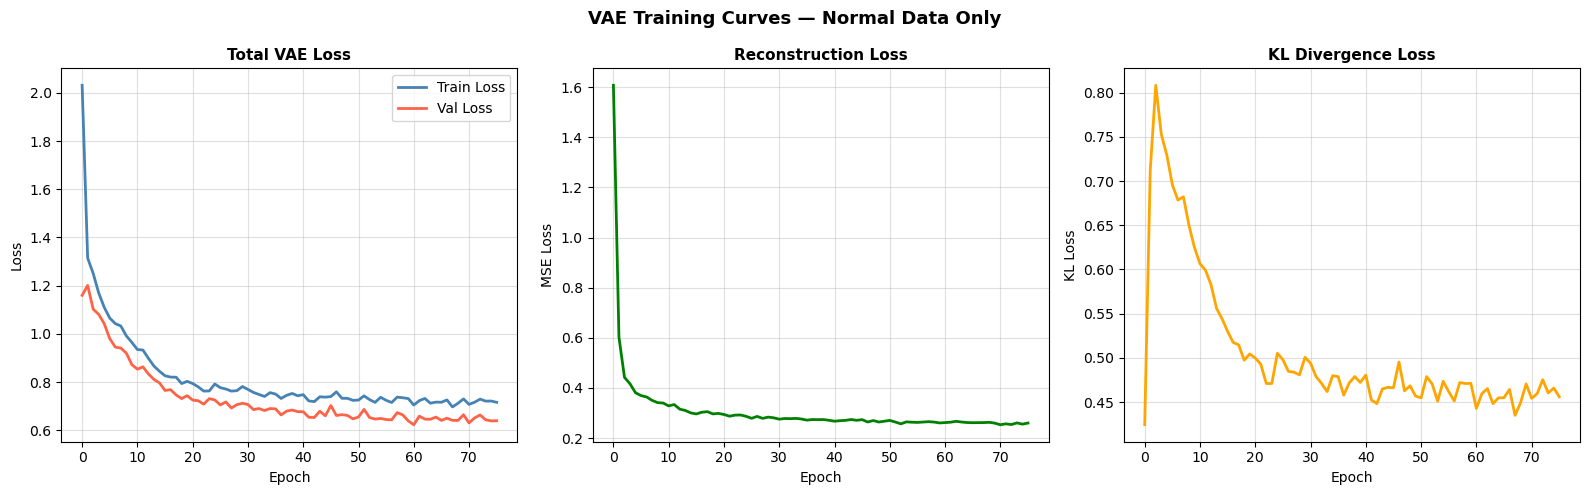

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(train_losses, color='steelblue', linewidth=2, label='Train Loss')
axes[0].plot(val_losses,   color='tomato',    linewidth=2, label='Val Loss')
axes[0].set_title('Total VAE Loss', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(recon_losses, color='green', linewidth=2)
axes[1].set_title('Reconstruction Loss', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].grid(True, alpha=0.4)

axes[2].plot(kl_losses, color='orange', linewidth=2)
axes[2].set_title('KL Divergence Loss', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('KL Loss')
axes[2].grid(True, alpha=0.4)

plt.suptitle('VAE Training Curves — Normal Data Only', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 6 — Anomaly Detection Threshold

**How to detect blockage using reconstruction error?**
```
Normal patients  → VAE ne pattern seekha → Low error ✅
Blockage patients → Pattern unfamiliar   → High error 🔴

Threshold = mean(normal_errors) + 2 * std(normal_errors)
Patient error > Threshold → BLOCKAGE detected!
```

In [8]:
# Reconstruction error for all patients
recon_err_all = vae.reconstruction_error(X_scaled)

# Separate normal and blockage errors
err_normal   = recon_err_all[y == 0]
err_blockage = recon_err_all[y == 1]

print('Normal    patients — Mean error:', round(err_normal.mean(),4),
      '| Std:', round(err_normal.std(),4))
print('Blockage  patients — Mean error:', round(err_blockage.mean(),4),
      '| Std:', round(err_blockage.std(),4))

# Threshold: mean + 2*std of normal errors
# WHY 2*std? Covers 95% of normal patients
threshold = err_normal.mean() + 2 * err_normal.std()
print(f'\nThreshold = mean + 2*std = {threshold:.4f}')

Normal    patients — Mean error: 0.2068 | Std: 0.0737
Blockage  patients — Mean error: 0.7748 | Std: 0.611

Threshold = mean + 2*std = 0.3543


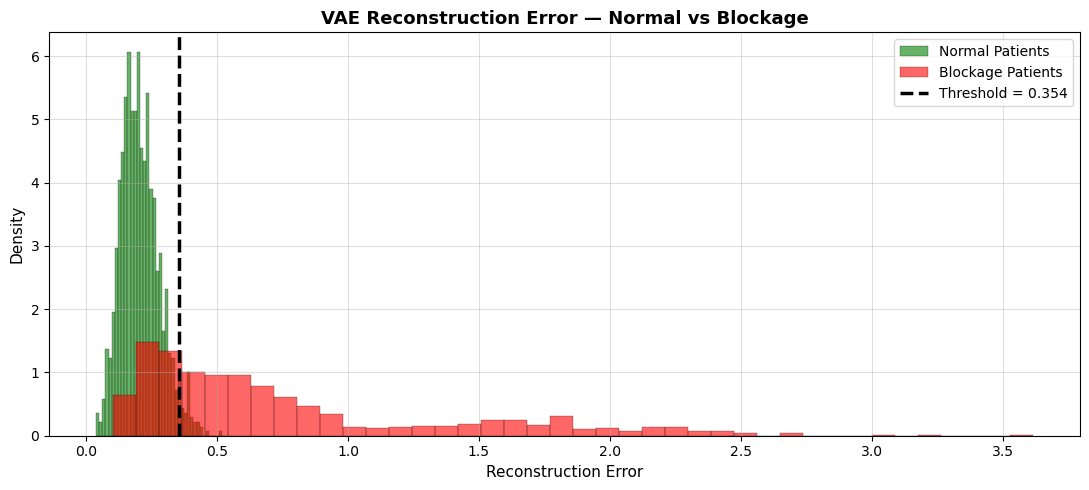

Patients correctly separated?
  Normal below threshold   : 95.8%
  Blockage above threshold : 70.7%


In [9]:
# Reconstruction error distribution plot
plt.figure(figsize=(11, 5))

plt.hist(err_normal,   bins=40, alpha=0.6, color='green',
         label='Normal Patients',   density=True, edgecolor='black', linewidth=0.3)
plt.hist(err_blockage, bins=40, alpha=0.6, color='red',
         label='Blockage Patients', density=True, edgecolor='black', linewidth=0.3)
plt.axvline(threshold, color='black', linewidth=2.5, linestyle='--',
            label=f'Threshold = {threshold:.3f}')
plt.xlabel('Reconstruction Error', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('VAE Reconstruction Error — Normal vs Blockage', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('Patients correctly separated?')
print(f'  Normal below threshold   : {(err_normal < threshold).mean()*100:.1f}%')
print(f'  Blockage above threshold : {(err_blockage > threshold).mean()*100:.1f}%')

---
## Step 7 — Test Set Evaluation

In [10]:
# Predict on test set
err_test = vae.reconstruction_error(X_test)
y_pred   = (err_test > threshold).astype(int)
y_prob   = err_test  # higher error = more likely blockage

# Normalize probabilities to 0-1
y_prob_norm = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-9)

acc  = accuracy_score(y_test,  y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test,    y_pred, zero_division=0)
f1   = f1_score(y_test,        y_pred, zero_division=0)
auc  = roc_auc_score(y_test,   y_prob_norm)

print('VAE TEST RESULTS')
print('='*40)
print(f'Accuracy  : {acc*100:.2f}%')
print(f'Precision : {prec*100:.2f}%')
print(f'Recall    : {rec*100:.2f}%')
print(f'F1-Score  : {f1*100:.2f}%')
print(f'ROC-AUC   : {auc:.4f}')
print('='*40)

VAE TEST RESULTS
Accuracy  : 82.67%
Precision : 88.66%
Recall    : 67.72%
F1-Score  : 76.79%
ROC-AUC   : 0.9047


In [11]:
print(classification_report(y_test, y_pred, target_names=['Normal','Blockage']))

              precision    recall  f1-score   support

      Normal       0.80      0.94      0.86       173
    Blockage       0.89      0.68      0.77       127

    accuracy                           0.83       300
   macro avg       0.84      0.81      0.81       300
weighted avg       0.84      0.83      0.82       300



---
## Step 8 — Confusion Matrix

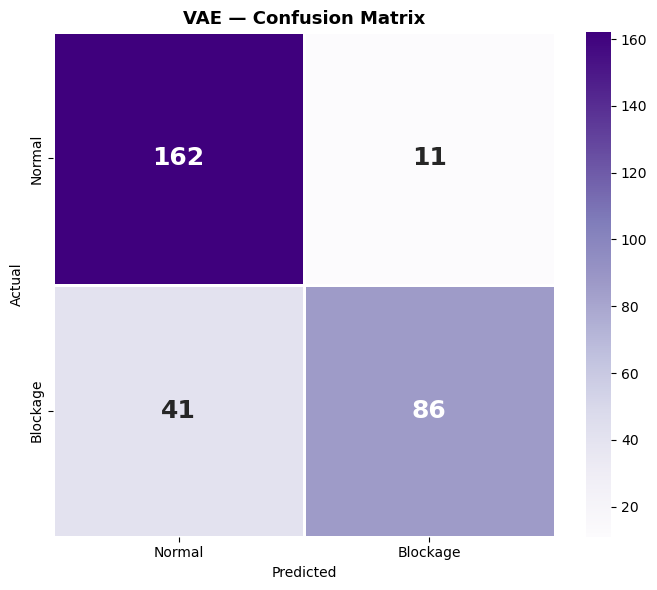

True  Normal   (TN): 162
False Alarm    (FP): 11
Missed Blockage(FN): 41
True  Blockage (TP): 86


In [12]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal','Blockage'],
            yticklabels=['Normal','Blockage'],
            linewidths=2, linecolor='white',
            annot_kws={'size':18,'weight':'bold'})
plt.title('VAE — Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f'True  Normal   (TN): {tn}')
print(f'False Alarm    (FP): {fp}')
print(f'Missed Blockage(FN): {fn}')
print(f'True  Blockage (TP): {tp}')

---
## Step 9 — ROC Curve

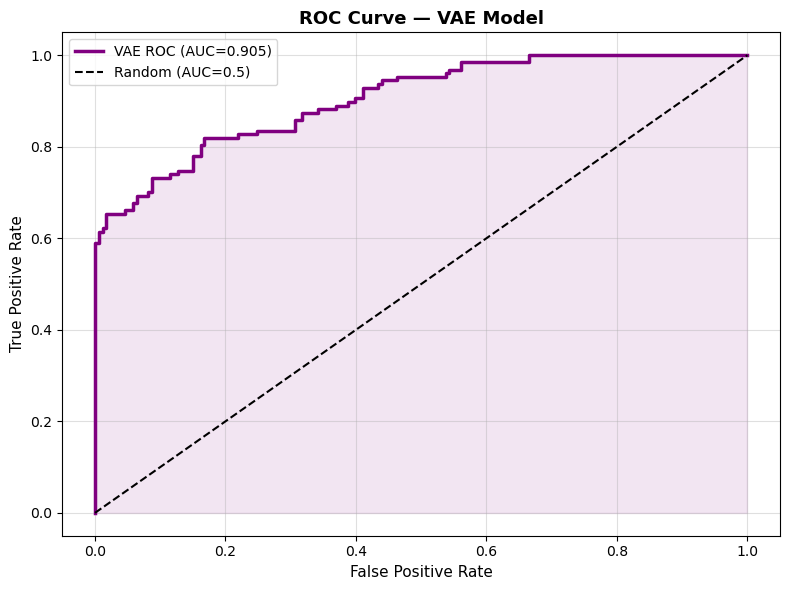

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob_norm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', linewidth=2.5,
         label=f'VAE ROC (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random (AUC=0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='purple')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve — VAE Model', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 10 — Latent Space Visualization

**VAE ka most powerful feature — Latent Space!**
```
15 features → compress → 3 dimensions (latent space)

Normal patients   → Ek cluster mein hone chahiye
Blockage patients → Alag cluster mein

Agar clearly separated hain → Model ne pattern samjha!
```

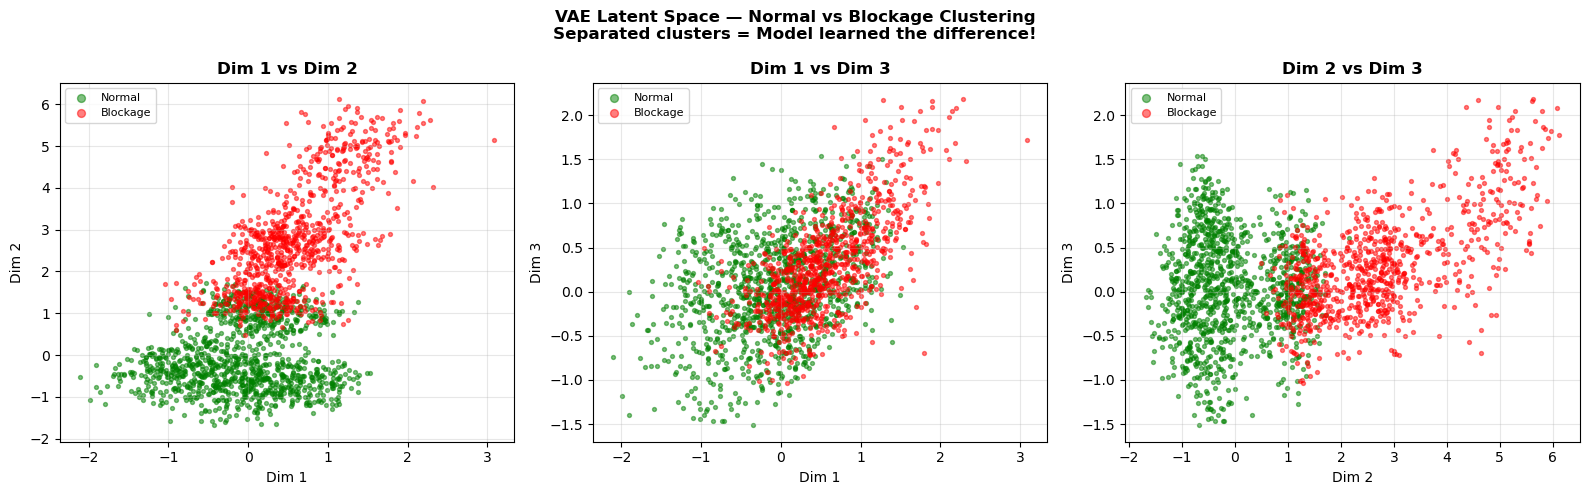

In [14]:
# Get latent representations
vae.training = False
_ = vae.forward(X_scaled)
latent_mu = vae.mu   # mean vectors (2000, 3)

normal_lat   = latent_mu[y == 0]
blockage_lat = latent_mu[y == 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [(0,1,'Dim 1','Dim 2'), (0,2,'Dim 1','Dim 3'), (1,2,'Dim 2','Dim 3')]
for ax, (i,j,xl,yl) in zip(axes, pairs):
    ax.scatter(normal_lat[:,i],   normal_lat[:,j],
               c='green', s=8, alpha=0.5, label='Normal')
    ax.scatter(blockage_lat[:,i], blockage_lat[:,j],
               c='red',   s=8, alpha=0.5, label='Blockage')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{xl} vs {yl}', fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('VAE Latent Space — Normal vs Blockage Clustering\n'
             'Separated clusters = Model learned the difference!',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 11 — Per-Patient Anomaly Score

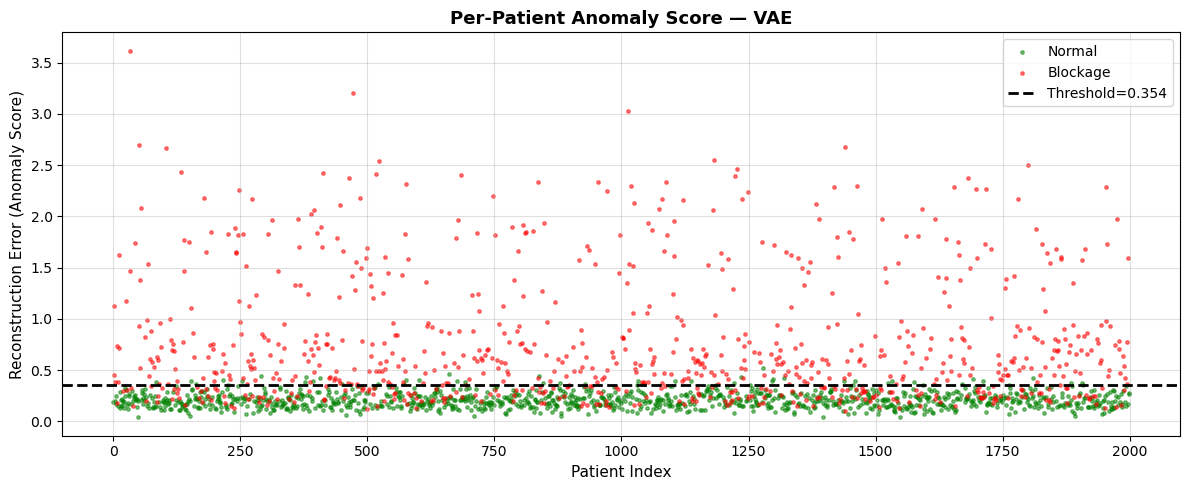

In [15]:
# All patients anomaly score
err_all = vae.reconstruction_error(X_scaled)
normal_idx   = np.where(y == 0)[0]
blockage_idx = np.where(y == 1)[0]

plt.figure(figsize=(12, 5))
plt.scatter(normal_idx,   err_all[normal_idx],
            c='green', s=6, alpha=0.5, label='Normal')
plt.scatter(blockage_idx, err_all[blockage_idx],
            c='red',   s=6, alpha=0.5, label='Blockage')
plt.axhline(threshold, color='black', linewidth=2, linestyle='--',
            label=f'Threshold={threshold:.3f}')
plt.xlabel('Patient Index', fontsize=11)
plt.ylabel('Reconstruction Error (Anomaly Score)', fontsize=11)
plt.title('Per-Patient Anomaly Score — VAE', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 12 — All 3 Models Comparison

In [16]:
# Load previous results
try:
    with open('phase3_mlp_results.pkl','rb') as f: mlp_r = pickle.load(f)
    mlp_acc,mlp_f1,mlp_auc = mlp_r['accuracy'],mlp_r['f1'],mlp_r['auc']
except: mlp_acc,mlp_f1,mlp_auc = 0.9567, 0.9494, 0.9937

try:
    with open('phase4_cnn_results.pkl','rb') as f: cnn_r = pickle.load(f)
    cnn_acc,cnn_f1,cnn_auc = cnn_r['accuracy'],cnn_r['f1'],cnn_r['auc']
except: cnn_acc,cnn_f1,cnn_auc = 0.95, 0.94, 0.99

comp = pd.DataFrame({
    'Model'     : ['MLP (Phase 3)','CNN+Attention (Phase 4)','VAE (Phase 5)'],
    'Accuracy%' : [round(mlp_acc*100,2), round(cnn_acc*100,2), round(acc*100,2)],
    'F1-Score%' : [round(mlp_f1*100,2),  round(cnn_f1*100,2),  round(f1*100,2)],
    'ROC-AUC'   : [round(mlp_auc,4),     round(cnn_auc,4),     round(auc,4)],
    'Type'      : ['Supervised','Supervised','Unsupervised']
})
print('All 3 Models Comparison:')
comp

All 3 Models Comparison:


,Model,Accuracy%,F1-Score%,ROC-AUC,Type
0,MLP (Phase 3),95.67,94.94,0.9937,Supervised
1,CNN+Attention (Phase 4),94.67,93.60,0.9872,Supervised
2,VAE (Phase 5),82.67,76.79,0.9047,Unsupervised


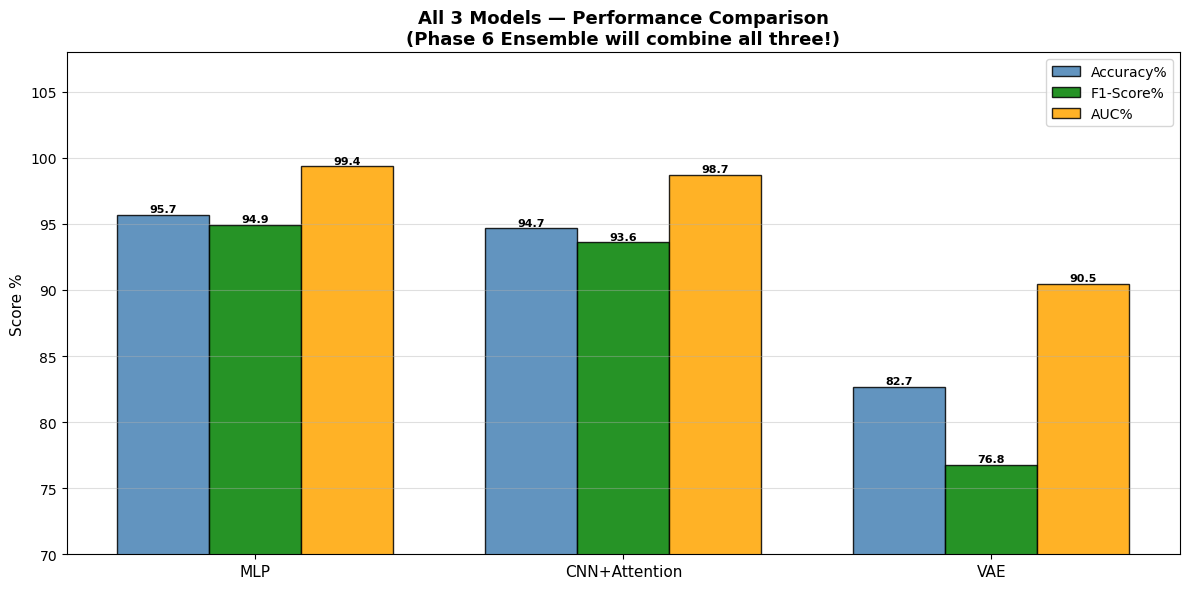

In [17]:
# Visual comparison — all 3 models
models   = ['MLP','CNN+Attention','VAE']
acc_vals = [mlp_acc*100, cnn_acc*100, acc*100]
f1_vals  = [mlp_f1*100,  cnn_f1*100,  f1*100]
auc_vals = [mlp_auc*100, cnn_auc*100, auc*100]

x=np.arange(3); width=0.25
plt.figure(figsize=(12, 6))
b1=plt.bar(x-width, acc_vals, width, label='Accuracy%', color='steelblue', edgecolor='black', alpha=0.85)
b2=plt.bar(x,       f1_vals,  width, label='F1-Score%', color='green',     edgecolor='black', alpha=0.85)
b3=plt.bar(x+width, auc_vals, width, label='AUC%',      color='orange',    edgecolor='black', alpha=0.85)

for bars in [b1,b2,b3]:
    for bar in bars:
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{bar.get_height():.1f}', ha='center', fontsize=8, fontweight='bold')

plt.xticks(x, models, fontsize=11)
plt.ylim(70, 108)
plt.ylabel('Score %', fontsize=11)
plt.title('All 3 Models — Performance Comparison\n(Phase 6 Ensemble will combine all three!)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 13 — Save VAE Model

In [18]:
# Save VAE
with open('phase5_vae_model.pkl','wb') as f:
    pickle.dump(vae, f)
with open('phase5_vae_scaler.pkl','wb') as f:
    pickle.dump(scaler, f)
np.save('phase5_threshold.npy', np.array([threshold]))

vae_results = {
    'name':'VAE','accuracy':acc,'precision':prec,
    'recall':rec,'f1':f1,'auc':auc,
    'y_prob_test':y_prob_norm,'y_test':y_test,
    'threshold':threshold
}
with open('phase5_vae_results.pkl','wb') as f:
    pickle.dump(vae_results, f)

print('Saved:')
print('  phase5_vae_model.pkl    ← Full VAE model')
print('  phase5_vae_scaler.pkl   ← Scaler')
print('  phase5_threshold.npy    ← Detection threshold')
print('  phase5_vae_results.pkl  ← Results for Ensemble Phase 6')

Saved:
  phase5_vae_model.pkl    ← Full VAE model
  phase5_vae_scaler.pkl   ← Scaler
  phase5_threshold.npy    ← Detection threshold
  phase5_vae_results.pkl  ← Results for Ensemble Phase 6


---
## Phase 5 Summary

In [19]:
print('='*45)
print('  PHASE 5 — VAE COMPLETE')
print('='*45)
print('Type         : Unsupervised (No labels needed!)')
print('Architecture : ENCODER: 15→64→32→[Mean(3),LogVar(3)]')
print('             : DECODER: 3→32→64→15')
print('Loss         : MSE + KL Divergence')
print('Training     : Normal patients only')
print('Detection    : Reconstruction error > threshold')
print('─'*45)
print(f'Accuracy     : {acc*100:.2f}%')
print(f'Precision    : {prec*100:.2f}%')
print(f'Recall       : {rec*100:.2f}%')
print(f'F1-Score     : {f1*100:.2f}%')
print(f'ROC-AUC      : {auc:.4f}')
print('='*45)
print('NEXT → PHASE 6: ENSEMBLE (All 3 Models Combined!)')
print('='*45)

  PHASE 5 — VAE COMPLETE
Type         : Unsupervised (No labels needed!)
Architecture : ENCODER: 15→64→32→[Mean(3),LogVar(3)]
             : DECODER: 3→32→64→15
Loss         : MSE + KL Divergence
Training     : Normal patients only
Detection    : Reconstruction error > threshold
─────────────────────────────────────────────
Accuracy     : 82.67%
Precision    : 88.66%
Recall       : 67.72%
F1-Score     : 76.79%
ROC-AUC      : 0.9047
NEXT → PHASE 6: ENSEMBLE (All 3 Models Combined!)
